In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.shape

(200, 5)

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [11]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

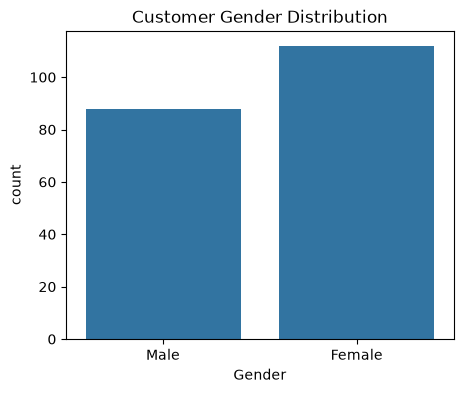

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df)

plt.title("Customer Gender Distribution")
plt.show()

In [13]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

## Insight - Customer Gender Distribution

The dataset contains 112 female customers and 88 male customers.

- Female customers outnumber male customers.
- This indicates that female customers form the larger customer group in the dataset.

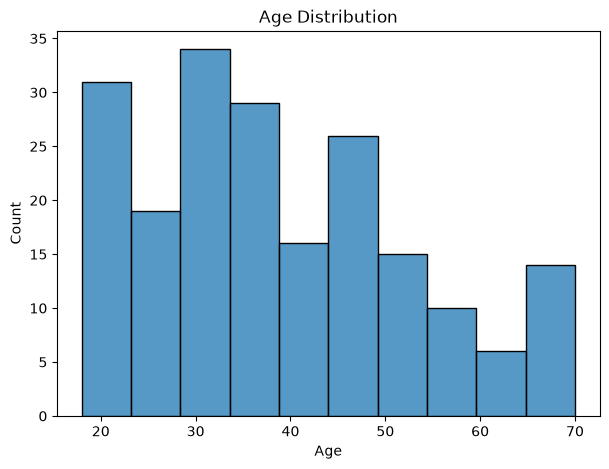

In [14]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## Insight - Age Distribution

The majority of customers are between 20 and 40 years old.

This indicates that young and middle-aged customers make up the largest customer group.

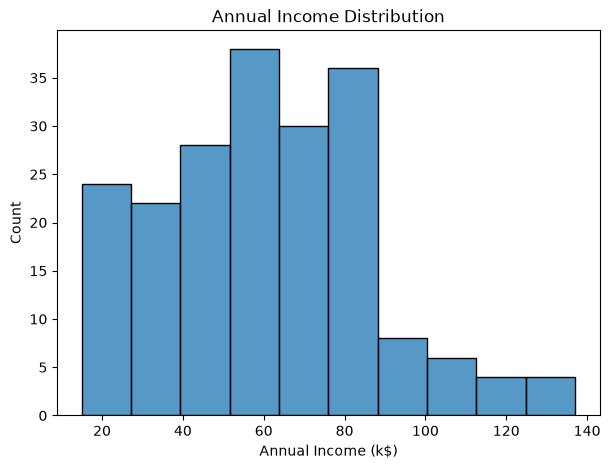

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(df['Annual Income (k$)'], bins=10)

plt.title("Annual Income Distribution")

plt.show()

## Insight - Annual Income Distribution

Customers have different income levels.

Most customers fall within the middle-income range, while fewer customers belong to very low or very high income groups.

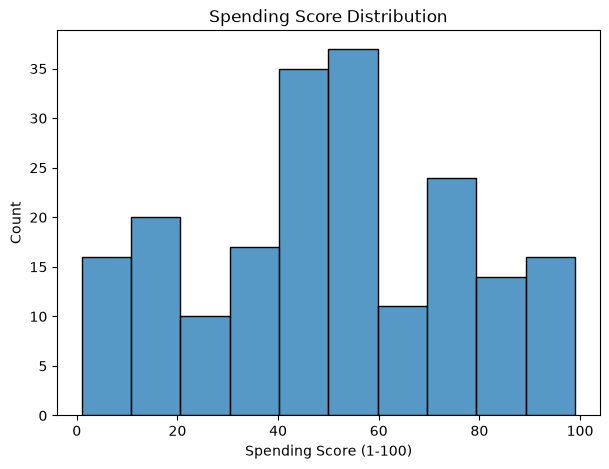

In [16]:
plt.figure(figsize=(7,5))
sns.histplot(df['Spending Score (1-100)'], bins=10)

plt.title("Spending Score Distribution")

plt.show()

## Insight - Spending Score Distribution

Customers have varying spending scores.

Some customers spend significantly more than others, making spending score an important feature for customer segmentation.

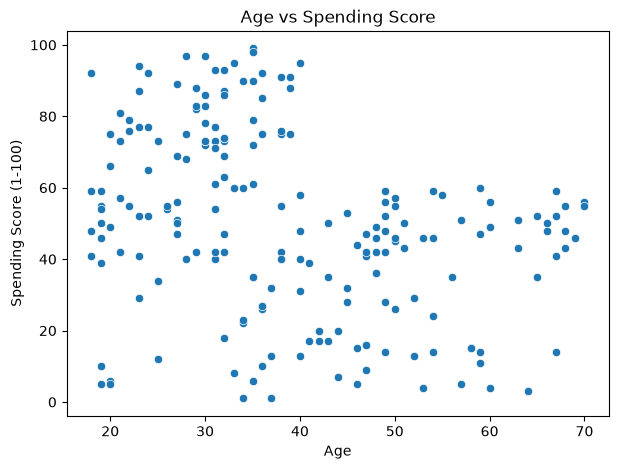

In [17]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Age vs Spending Score")

plt.show()

## Insight - Age vs Spending Score

Younger customers generally have higher spending scores, while older customers tend to spend less.

This suggests that age may influence customer purchasing behavior.

In [18]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


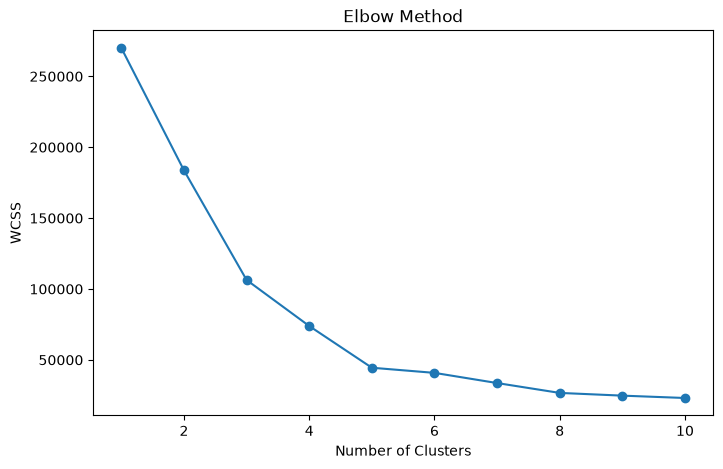

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [22]:
df = pd.read_csv("Mall_Customers.csv")

In [23]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


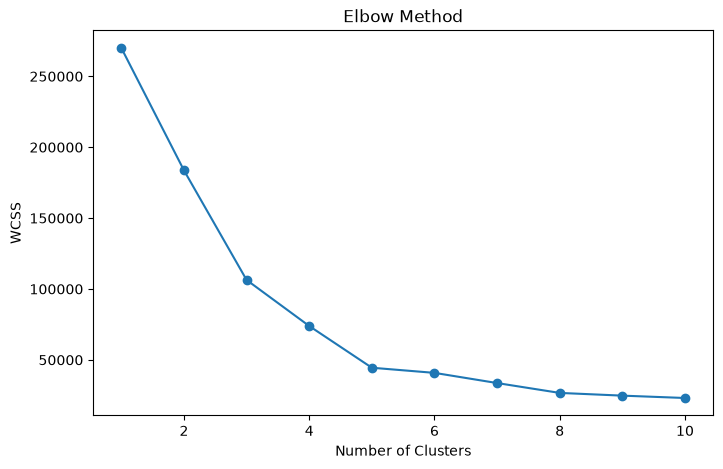

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Insight - Elbow Method

The Elbow Method helps determine the optimal number of customer clusters.

- The WCSS decreases as the number of clusters increases.
- A noticeable bend (elbow) appears around **5 clusters**.
- Therefore, **5** is selected as the optimal number of customer segments.

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


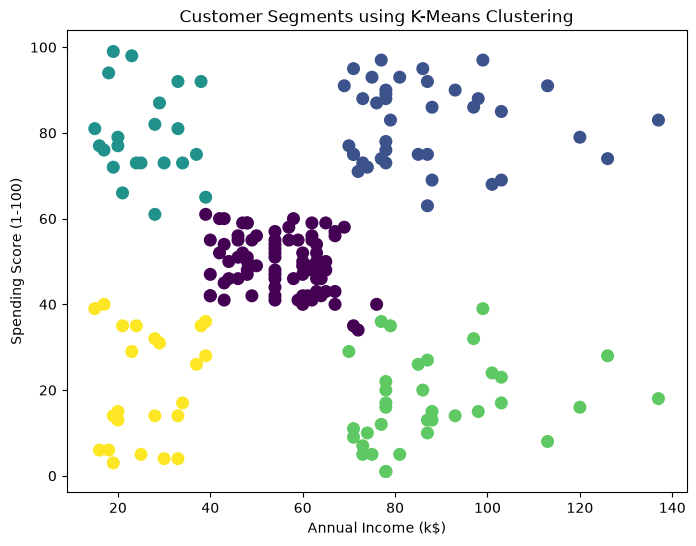

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means Clustering")

plt.show()

## Insight - Customer Segments

The K-Means algorithm grouped customers into **5 distinct segments** based on their annual income and spending score.

- Customers with high income and high spending are valuable customers.
- Customers with high income but low spending may require targeted promotions.
- Customers with low income and high spending represent frequent buyers.
- Customers with low income and low spending are budget-conscious customers.
- These customer segments help businesses create personalized marketing strategies.

In [28]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

## Insight - Cluster Distribution

The customer segmentation process grouped the customers into **5 different clusters**.

- The largest customer group contains **81 customers**.
- The remaining clusters contain **39**, **35**, **23**, and **22** customers respectively.
- The cluster sizes vary, indicating that customers are distributed differently based on their annual income and spending score.

This segmentation helps businesses understand different customer groups and develop personalized marketing strategies for each segment.

# Business Insights

Based on the customer segmentation analysis, the following insights were identified:

- Customers were successfully divided into **5 different segments** using the K-Means clustering algorithm.
- The largest customer segment contains **81 customers**, while the smallest segment contains **22 customers**.
- Customer groups have different spending behaviors and annual income levels.
- Businesses can create personalized marketing campaigns for each customer segment.
- High-value customers can be rewarded through loyalty programs, while low-spending customers can be encouraged with discounts and promotional offers.

# Conclusion

This project successfully performed Customer Segmentation Analysis using the K-Means Clustering algorithm.

The dataset was cleaned, explored, and visualized using Python libraries such as Pandas, Matplotlib, and Seaborn. Finally, customers were grouped into five clusters based on their annual income and spending score.

Customer segmentation helps businesses better understand customer behavior, improve marketing strategies, and increase customer satisfaction by offering personalized services.